# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
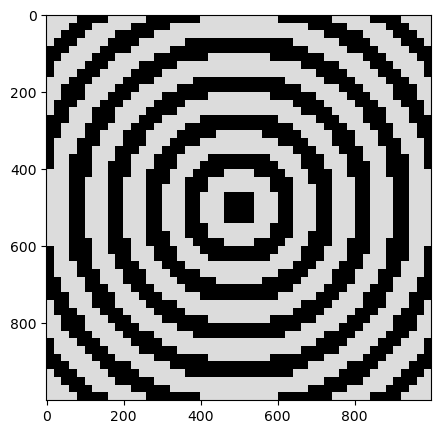


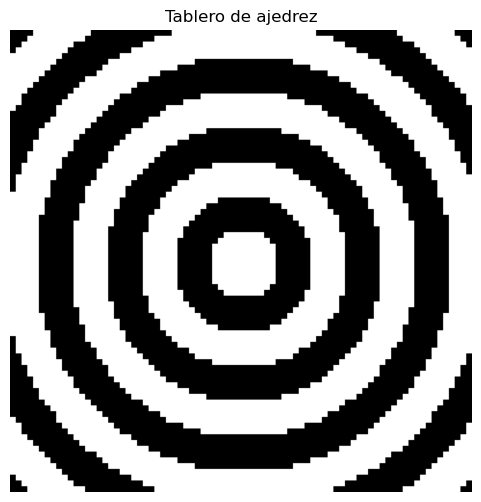

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [6, 6]


n = 80            
bloque = 20         
size = n * bloque 

R = np.zeros((size, size))
G = np.zeros((size, size))
B = np.zeros((size, size))

#bloque del medio 
cx = n // 2
cy = n // 2
#anillo
ancho_anillo = 6

for i in range(n):
    for j in range(n):

        r0 = i * bloque
        r1 = (i + 1) * bloque
        c0 = j * bloque
        c1 = (j + 1) * bloque

        dist = np.sqrt((i - cy)**2 + (j - cx)**2)

        anillo = int(dist // ancho_anillo)

        if anillo % 2 == 0:
            rv, gv, bv = 255, 255, 255
        else:
            rv, gv, bv = 0, 0, 0

        # ASIGNAR BLOQUE
        R[r0:r1, c0:c1] = rv
        G[r0:r1, c0:c1] = gv
        B[r0:r1, c0:c1] = bv

imagen = np.dstack((R, G, B)).astype(np.uint8)

plt.imshow(imagen)
plt.title("Tablero de ajedrez")
plt.axis("off")
plt.show()


# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
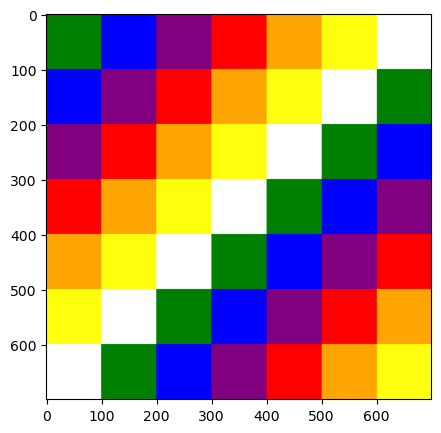

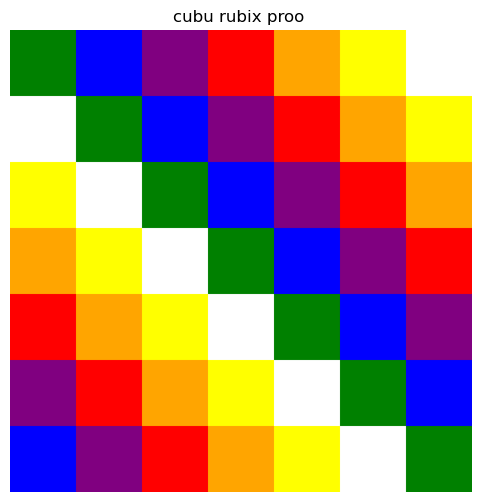

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [6, 6]

n = 7                     
size = 700
bloque = size // n

R = np.zeros((size, size))
G = np.zeros((size, size))
B = np.zeros((size, size))

colores = [
    (0, 128, 0),      
    (0, 0, 255),      
    (128, 0, 128),    
    (255, 0, 0),      
    (255, 165, 0),    
    (255, 255, 0),    
    (255, 255, 255)   
]


for i in range(n):
    for j in range(n):

        r0 = i * bloque
        r1 = (i + 1) * bloque
        c0 = j * bloque
        c1 = (j + 1) * bloque

    
        index = (j - i) % len(colores)

        rv, gv, bv = colores[index]

        R[r0:r1, c0:c1] = rv
        G[r0:r1, c0:c1] = gv
        B[r0:r1, c0:c1] = bv

imagen = np.dstack((R, G, B)).astype(np.uint8)

plt.imshow(imagen)
plt.title("cubu rubix proo ")
plt.axis("off")
plt.show()


# Ejercicio 3.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

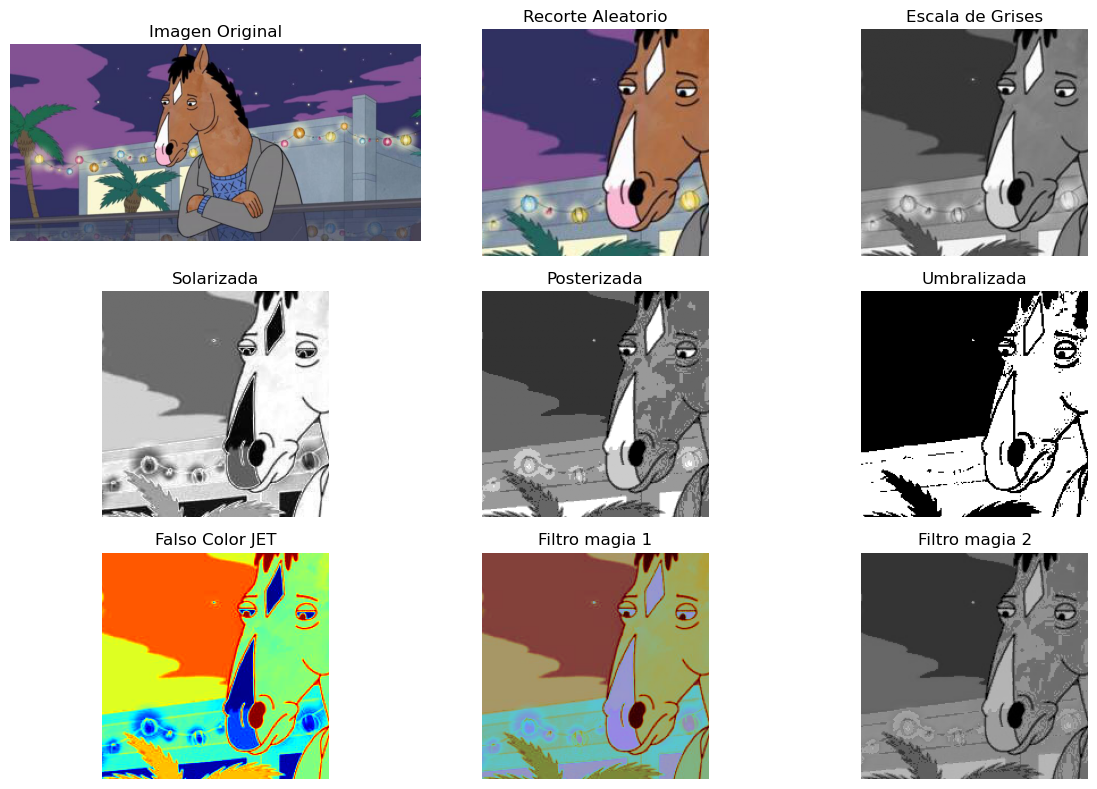

True

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

img = cv2.imread('imagen1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img_rgb.shape

#random
x = random.randint(0, w - 200)
y = random.randint(0, h - 200)

recorte = img_rgb[y:y+200, x:x+200]


def solarizar(imagen, umbral):
    return np.where(imagen < umbral, imagen, 255 - imagen)

def posterizar(imagen, niveles):
    factor = 256 // niveles
    return (np.round(imagen / factor) * factor).astype(np.uint8)

def umbral_binario(img_gray, umbral=127):
    _, th = cv2.threshold(img_gray, umbral, 255, cv2.THRESH_BINARY)
    return th

def falso_color(img_gray, mapa):
    escala = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)
    return cv2.applyColorMap(escala, mapa)


gray = cv2.cvtColor(recorte, cv2.COLOR_RGB2GRAY)

#sol
img_solar = solarizar(gray, 128)

# pos
img_post = posterizar(gray, 5)

# umbr
img_umbral = umbral_binario(gray, 120)

# fal colo
fc_jet = falso_color(gray, cv2.COLORMAP_JET)

#magia
mezcla1 = cv2.addWeighted(recorte, 0.6, fc_jet, 0.4, 0)
mezcla2 = cv2.addWeighted(cv2.cvtColor(img_post, cv2.COLOR_GRAY2RGB), 0.7,
                          cv2.cvtColor(img_solar, cv2.COLOR_GRAY2RGB), 0.3, 0)

#visu
plt.figure(figsize=(12,8))

plt.subplot(3,3,1)
plt.imshow(img_rgb)
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(recorte)
plt.title("Recorte Aleatorio")
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(gray, cmap='gray')
plt.title("Escala de Grises")
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(img_solar, cmap='gray')
plt.title("Solarizada")
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(img_post, cmap='gray')
plt.title("Posterizada")
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(img_umbral, cmap='gray')
plt.title("Umbralizada")
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(fc_jet)
plt.title("Falso Color JET")
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(mezcla1)
plt.title("Filtro magia 1")
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(mezcla2)
plt.title("Filtro magia 2")
plt.axis('off')

plt.tight_layout()
plt.show()
#guarda
cv2.imwrite("recorte.png", cv2.cvtColor(recorte, cv2.COLOR_RGB2BGR))
cv2.imwrite("gris.png", gray)
cv2.imwrite("solarizada.png", img_solar)
cv2.imwrite("posterizada.png", img_post)
cv2.imwrite("umbral.png", img_umbral)
cv2.imwrite("falso_color.png", fc_jet)
cv2.imwrite("artistico1.png", cv2.cvtColor(mezcla1, cv2.COLOR_RGB2BGR))
cv2.imwrite("artistico2.png", cv2.cvtColor(mezcla2, cv2.COLOR_RGB2BGR))


# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 